In [1]:
from transformers import AutoTokenizer
import torch
import numpy as np
import functools
from sklearn import metrics
from torch.utils.data import DataLoader
import sys

PATH = '/home/skrhakv/Projects/seq2pocket'
torch.manual_seed(42)

sys.path.append(f'{PATH}/src/utils')
sys.path.append(f'{PATH}/../cryptic-nn/src')

import finetuning_utils # download from https://github.com/skrhakv/cryptic-finetuning/blob/master/src/finetuning_utils.py
from finetuning_utils import FinetunedEsmModel
import eval_utils
from eval_utils import CryptoBenchClassifier
import cryptoshow_utils
import clustering_utils

MODEL_NAME = 'facebook/esm2_t36_3B_UR50D'
device = 'cuda' if torch.cuda.is_available() else 'cpu'

MODEL_PATH = f'{PATH}/data/models/gbs-model-enhanced-scPDB-filtered.pt'

SMOOTHING_MODEL_PATH = f'{PATH}/data/models/smoother.pt'
smoothing_model = torch.load(SMOOTHING_MODEL_PATH, weights_only=False) #, map_location=torch.device('cpu'))

ESM_EMBEDDINGS_PATH = f'{PATH}/data/embeddings/coach420'
COORDINATES_DIR = f'{PATH}/data/coordinates/coach420'
POSITIVE_DISTANCE_THRESHOLD = 15
PRECALCULATED = False
PREDICTIONS_PATH = f'{PATH}/data/predictions'
PRECALCULATED_PATH = f'{PREDICTIONS_PATH}/gbs-model'
ANNOTATION_PATH = f'{PATH}/data/data-extraction/coach420_for_pocket_level_evaluation.csv'
DECISION_THRESHOLD = 0.7


In [5]:
%load_ext autoreload
%autoreload 2
import clustering_utils

import pickle

model = torch.load(MODEL_PATH, weights_only=False)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

binding_residues, sequences = eval_utils.read_test_binding_residues(data_path=ANNOTATION_PATH, pocket_types=['NON_CRYPTIC'])

predicted_binding_sites = {}
ranks = {}
prediction_scores = {}

K = 2

DCCs_N = []
DCCs_N_plus_K = []
DCCs = []

is_small_pocket_DCC_N = []
is_small_pocket_DCC_N_plus_K = []
is_small_pocket_DCC = []

number_of_added_residues = []

number_of_overlapping_predictions_on_actual_pocket = []
number_of_overlapping_actual_sites_on_predicted_pocket = []
best_residue_overlaps = []

for i, protein_id in enumerate(sequences.keys()):
    pdb_id, chain_id = protein_id.split('_')
    sequence = sequences[protein_id]
    embeddings_path = f'{ESM_EMBEDDINGS_PATH}/{pdb_id}{chain_id}.npy'
    coordinates_path = f'{COORDINATES_DIR}/{pdb_id}{chain_id}.npy'
    actual_binding_sites = [np.array([int(i.split('_')[1]) for i in pocket]) for pocket in binding_residues[protein_id]]
    
    print(f'Processing {protein_id} ({i+1}/{len(sequences)})...')
    if not PRECALCULATED:
        # finetuned prediction
        probabilities = eval_utils.compute_prediction(
            sequence,
            model,
            tokenizer
        )
    else:
        # load precalculated prediction
        probabilities = np.load(f'{PRECALCULATED_PATH}/{protein_id.replace("_","")}.npy')
    
    prediction_scores[protein_id] = probabilities

    coordinates = np.load(coordinates_path)
    distance_matrix = eval_utils.compute_distance_matrix(coordinates)

    predictions = (probabilities > DECISION_THRESHOLD).astype(float)
    predictions_copy = predictions.copy()

    assert distance_matrix.shape[0] == distance_matrix.shape[1]
    assert distance_matrix.shape[0] == predictions_copy.shape[0]
    
    X_test = np.load(embeddings_path)
    assert X_test.shape[0] == distance_matrix.shape[0]

    # loop over the residues that are not binding and are potential candidates for smoothing
    additional_residues = []
    added_residues_count = 0
    for residue_idx in np.where(predictions == 0.0)[0]:

        # get the embedding of the residue
        current_residue_embedding = X_test[residue_idx]

        # get the close binding residues
        close_residues_indices = np.where(distance_matrix[residue_idx] < POSITIVE_DISTANCE_THRESHOLD)[0]
        close_binding_residues_indices = np.intersect1d(close_residues_indices, np.where(predictions == 1.0)[0])
        # create embedding 
        if len(close_binding_residues_indices) == 0:
            # no close binding residues - skip this residue
            continue
        elif len(close_binding_residues_indices) == 1:
            surrounding_embedding = X_test[close_binding_residues_indices].reshape(-1)
        else:
            # get the mean of the close binding residues
            surrounding_embedding = np.mean(X_test[close_binding_residues_indices], axis=0).reshape(-1)

        concatenated_embedding = torch.tensor(np.concatenate((current_residue_embedding, surrounding_embedding), axis=0), dtype=torch.float32).to(device)
        
        # get the prediction
        test_logits = smoothing_model(concatenated_embedding).squeeze()
        result = (torch.sigmoid(test_logits)>eval_utils.SMOOTHING_DECISION_THRESHOLD).float()
        if result == 1:
            # set the residue as binding
            # print(f"Smoothing changed residue {residue_idx} in protein {protein_id} to binding")
            additional_residues.append(residue_idx)
            predictions_copy[residue_idx] = 1
            added_residues_count += 1

    number_of_added_residues.append(added_residues_count)
    indices_above_threshold = np.where(predictions_copy > DECISION_THRESHOLD)[0] # this gets residues that are equal to 1
    # no predicted residues - continue
    if len(indices_above_threshold) == 0:
        continue

    # run atom-level clustering and return residue-level pockets
    clusters, cluster_residues, cluster_scores, atom_coords, residue_coords = clustering_utils.execute_atom_clustering(
        pdb_id,
        chain_id,
        indices_above_threshold,
        probabilities[indices_above_threshold],
        eps=9,
        scoring_method='mean'
    )

    # none of the residues are on the surface
    if cluster_residues is None:
        continue

    cluster_residues = cryptoshow_utils.map_auth_to_mmcif_numbering_array(
        pdb_id,
        chain_id,
        cluster_residues.values(),
        binding_residues_are_integers=True,
        numbers_only=True
    )[0]

    cluster_order = np.argsort(cluster_scores)[::-1]  # descending order
    N = len(actual_binding_sites)

    selected_clusters_N = cluster_order[:N]
    selected_clusters_N_plus_K = cluster_order[:N+K]

    predicted_centers = {}
    for cluster_label, atom_indices in clusters.items():
        cluster_coords = np.array([atom_coords[atom_id] for atom_id in atom_indices])
        cluster_center = np.mean(cluster_coords, axis=0).get_array()
        predicted_centers[cluster_label] = cluster_center
    
    actual_centers = []
    is_small_pocket = []
    for pocket in actual_binding_sites:
        pocket_coords = coordinates[pocket]
        pocket_center = np.mean(pocket_coords, axis=0)
        actual_centers.append(pocket_center)
        is_small_pocket.append(len(pocket) < 10)
    
    for i, center in enumerate(actual_centers):
        DCC_N = float('inf')
        for j in selected_clusters_N:
            predicted_center = predicted_centers[j]
            distance = np.linalg.norm(center - predicted_center)
            if distance < DCC_N:
                DCC_N = distance
        
        if DCC_N != float('inf'):
            DCCs_N.append(DCC_N)
            is_small_pocket_DCC_N.append(is_small_pocket[i])

        DCC_N_plus_K = float('inf')
        for j in selected_clusters_N_plus_K:
            predicted_center = predicted_centers[j]
            distance = np.linalg.norm(center - predicted_center)
            if distance < DCC_N_plus_K:
                DCC_N_plus_K = distance
        
        if DCC_N_plus_K != float('inf'):
            DCCs_N_plus_K.append(DCC_N_plus_K)
            is_small_pocket_DCC_N_plus_K.append(is_small_pocket[i])
            
        DCC = float('inf')
        for j, predicted_center in predicted_centers.items():
            distance = np.linalg.norm(center - predicted_center)
            if distance < DCC:
                DCC = distance    

        if DCC != float('inf'):
            DCCs.append(DCC)
            is_small_pocket_DCC.append(is_small_pocket[i])

    for pocket in actual_binding_sites:
        number_of_predicted_pockets = 0
        best_residue_overlap = 0
        for residues in cluster_residues:
            residue_overlap = len(set(pocket).intersection(residues)) / len(pocket)
            if residue_overlap > best_residue_overlap:
                best_residue_overlap = residue_overlap
            if any(residue in pocket for residue in residues):
                number_of_predicted_pockets += 1
        number_of_overlapping_actual_sites_on_predicted_pocket.append(number_of_predicted_pockets)
        if best_residue_overlap > 0:
            best_residue_overlaps.append(best_residue_overlap)

    for residues in cluster_residues:
        number_of_predicted_pockets = 0
        for pocket in actual_binding_sites:
            if any(residue in pocket for residue in residues):
                number_of_predicted_pockets += 1
        number_of_overlapping_predictions_on_actual_pocket.append(number_of_predicted_pockets)

    # with open(f'{PATH}/data/visualizations/predictions/coach420/{protein_id.replace("_", "")}.pkl', 'wb') as f:
    #     pickle.dump((cluster_residues, additional_residues), f)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Processing 148l_E (1/420)...
Processing 1a26_A (2/420)...
Processing 1a4k_H (3/420)...
Processing 1a7x_A (4/420)...
Processing 1a8t_A (5/420)...
Processing 1afk_A (6/420)...
Processing 1arc_A (7/420)...
Processing 1atl_A (8/420)...
Processing 1b8u_A (9/420)...
Processing 1blc_A (10/420)...
Processing 1bnw_A (11/420)...
Processing 1bq3_A (12/420)...
Processing 1bqo_B (13/420)...
Processing 1br6_A (14/420)...
Processing 1bs1_A (15/420)...
Processing 1bsv_A (16/420)...
Processing 1bxq_A (17/420)...
Processing 1bzy_A (18/420)...
Processing 1c1h_A (19/420)...
Processing 1c3j_A (20/420)...
Processing 1c5i_A (21/420)...
Processing 1cen_A (22/420)...
Processing 1cet_A (23/420)...
Processing 1ch8_A (24/420)...
Processing 1cim_A (25/420)...
Processing 1cqf_B (26/420)...
Processing 1d3p_B (27/420)...
Processing 1d4p_B (28/420)...
Processing 1dcp_A (29/420)...
Processing 1ddt_A (30/420)...
Processing 1e3v_A (31

best_residue_overlap mean=0.6975, median=0.7143
0.9833333333333333 (0.3333333333333333)
0.9261904761904762 (0.3119047619047619)
0.7547619047619047 (0.24047619047619048)

Small binding pockets (less than 10 residues):
Overall DCC < 12: 0.9836 (0.2459)
N+K DCC < 12: 0.9672 (0.2295)
N DCC < 12: 0.7705 (0.1639)

Large binding pockets (10 or more residues):
Overall DCC < 12: 0.9833 (0.3482)
N+K DCC < 12: 0.9192 (0.3259)
N DCC < 12: 0.7521 (0.2535)


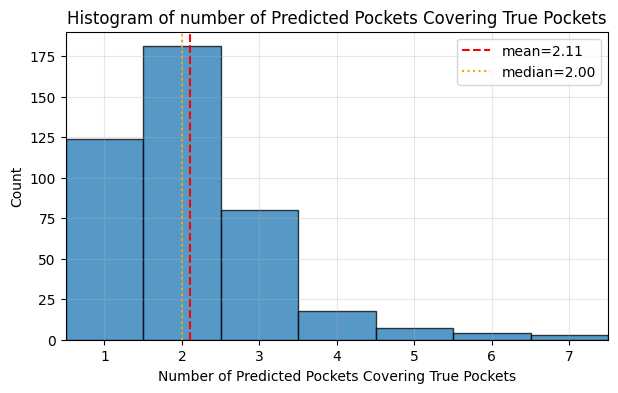

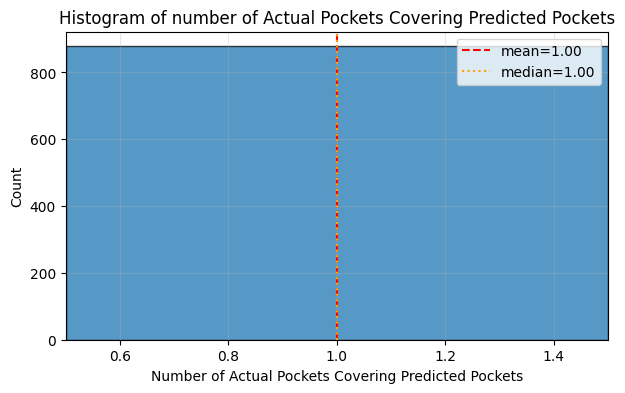

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

number_of_pockets = sum([len(i) for i in binding_residues.values()])

mean_br = np.mean(best_residue_overlaps)
median_br = np.median(best_residue_overlaps)
print(f'best_residue_overlap mean={mean_br:.4f}, median={median_br:.4f}')

print(np.sum(np.array(DCCs) < 12) / number_of_pockets, f'({np.sum(np.array(DCCs) < 4) / number_of_pockets})')
print(np.sum(np.array(DCCs_N_plus_K) < 12) / number_of_pockets, f'({np.sum(np.array(DCCs_N_plus_K) < 4) / number_of_pockets})')
print(np.sum(np.array(DCCs_N) < 12) / number_of_pockets, f'({np.sum(np.array(DCCs_N) < 4) / number_of_pockets})')


print('\nSmall binding pockets (less than 10 residues):')
small_pockets_DCCs = [DCCs[i] for i in range(len(DCCs)) if is_small_pocket_DCC[i]]
print(f'Overall DCC < 12: {np.sum(np.array(small_pockets_DCCs) < 12) / len(small_pockets_DCCs):.4f} ({np.sum(np.array(small_pockets_DCCs) < 4) / len(small_pockets_DCCs):.4f})')
small_pockets_DCCs_N_plus_K = [DCCs_N_plus_K[i] for i in range(len(DCCs_N_plus_K)) if is_small_pocket_DCC_N_plus_K[i]]
print(f'N+K DCC < 12: {np.sum(np.array(small_pockets_DCCs_N_plus_K) < 12) / len(small_pockets_DCCs_N_plus_K):.4f} ({np.sum(np.array(small_pockets_DCCs_N_plus_K) < 4) / len(small_pockets_DCCs_N_plus_K):.4f})')
small_pockets_DCCs_N = [DCCs_N[i] for i in range(len(DCCs_N)) if is_small_pocket_DCC_N[i]]
print(f'N DCC < 12: {np.sum(np.array(small_pockets_DCCs_N) < 12) / len(small_pockets_DCCs_N):.4f} ({np.sum(np.array(small_pockets_DCCs_N) < 4) / len(small_pockets_DCCs_N):.4f})')

print('\nLarge binding pockets (10 or more residues):')
large_pockets_DCCs = [DCCs[i] for i in range(len(DCCs)) if not is_small_pocket_DCC[i]]
print(f'Overall DCC < 12: {np.sum(np.array(large_pockets_DCCs) < 12) / len(large_pockets_DCCs):.4f} ({np.sum(np.array(large_pockets_DCCs) < 4) / len(large_pockets_DCCs):.4f})')
large_pockets_DCCs_N_plus_K = [DCCs_N_plus_K[i] for i in range(len(DCCs_N_plus_K)) if not is_small_pocket_DCC_N_plus_K[i]]
print(f'N+K DCC < 12: {np.sum(np.array(large_pockets_DCCs_N_plus_K) < 12) / len(large_pockets_DCCs_N_plus_K):.4f} ({np.sum(np.array(large_pockets_DCCs_N_plus_K) < 4) / len(large_pockets_DCCs_N_plus_K):.4f})')
large_pockets_DCCs_N = [DCCs_N[i] for i in range(len(DCCs_N)) if not is_small_pocket_DCC_N[i]]
print(f'N DCC < 12: {np.sum(np.array(large_pockets_DCCs_N) < 12) / len(large_pockets_DCCs_N):.4f} ({np.sum(np.array(large_pockets_DCCs_N) < 4) / len(large_pockets_DCCs_N):.4f})')  


fig, ax = plt.subplots(figsize=(7, 4))

# Remove zeros
number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros = [i for i in number_of_overlapping_actual_sites_on_predicted_pocket if i != 0]
bins = np.arange(-0.5, max(number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros) + 1.5, 1)
ax.clear()
ax.hist(number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros, bins=bins, color='C0', edgecolor='k', alpha=0.75)
mean_cov = np.mean(number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros)
median_cov = np.median(number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros)
ax.axvline(mean_cov, color='red', linestyle='--', label=f"mean={mean_cov:.2f}")
ax.axvline(median_cov, color='orange', linestyle=':', label=f"median={median_cov:.2f}")
ax.set_title("Histogram of number of Predicted Pockets Covering True Pockets")
ax.set_xlim(0.5, max(number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros) + 0.5)
ax.set_xlabel("Number of Predicted Pockets Covering True Pockets")
ax.set_ylabel("Count")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))

# Remove zeros
number_of_overlapping_predictions_on_actual_pocket_without_zeros = [i for i in number_of_overlapping_predictions_on_actual_pocket if i != 0]
bins = np.arange(-0.5, max(number_of_overlapping_predictions_on_actual_pocket_without_zeros) + 1.5, 1)
ax.clear()
ax.hist(number_of_overlapping_predictions_on_actual_pocket_without_zeros, bins=bins, color='C0', edgecolor='k', alpha=0.75)
mean_cov = np.mean(number_of_overlapping_predictions_on_actual_pocket_without_zeros)
median_cov = np.median(number_of_overlapping_predictions_on_actual_pocket_without_zeros)
ax.axvline(mean_cov, color='red', linestyle='--', label=f"mean={mean_cov:.2f}")
ax.axvline(median_cov, color='orange', linestyle=':', label=f"median={median_cov:.2f}")
ax.set_title("Histogram of number of Actual Pockets Covering Predicted Pockets")
ax.set_xlim(0.5, max(number_of_overlapping_predictions_on_actual_pocket_without_zeros) + 0.5)
ax.set_xlabel("Number of Actual Pockets Covering Predicted Pockets")
ax.set_ylabel("Count")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


In [7]:
%load_ext autoreload
%autoreload 2
import clustering_utils

import pickle

model = torch.load(MODEL_PATH, weights_only=False)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

binding_residues, sequences = eval_utils.read_test_binding_residues(data_path=ANNOTATION_PATH, pocket_types=['NON_CRYPTIC'])

predicted_binding_sites = {}
ranks = {}
prediction_scores = {}

K = 2

DCCs_N = []
DCCs_N_plus_K = []
DCCs = []

is_small_pocket_DCC_N = []
is_small_pocket_DCC_N_plus_K = []
is_small_pocket_DCC = []

number_of_added_residues = []

number_of_overlapping_predictions_on_actual_pocket = []
number_of_overlapping_actual_sites_on_predicted_pocket = []
best_residue_overlaps = []

for i, protein_id in enumerate(sequences.keys()):
    pdb_id, chain_id = protein_id.split('_')
    sequence = sequences[protein_id]
    embeddings_path = f'{ESM_EMBEDDINGS_PATH}/{pdb_id}{chain_id}.npy'
    coordinates_path = f'{COORDINATES_DIR}/{pdb_id}{chain_id}.npy'
    actual_binding_sites = [np.array([int(i.split('_')[1]) for i in pocket]) for pocket in binding_residues[protein_id]]
    
    print(f'Processing {protein_id} ({i+1}/{len(sequences)})...')
    if not PRECALCULATED:
        # finetuned prediction
        probabilities = eval_utils.compute_prediction(
            sequence,
            model,
            tokenizer
        )
    else:
        # load precalculated prediction
        probabilities = np.load(f'{PRECALCULATED_PATH}/{protein_id.replace("_","")}.npy')
    
    prediction_scores[protein_id] = probabilities

    coordinates = np.load(coordinates_path)
    distance_matrix = eval_utils.compute_distance_matrix(coordinates)

    predictions = (probabilities > DECISION_THRESHOLD).astype(float)
    predictions_copy = predictions.copy()

    assert distance_matrix.shape[0] == distance_matrix.shape[1]
    assert distance_matrix.shape[0] == predictions_copy.shape[0]
    
    X_test = np.load(embeddings_path)
    assert X_test.shape[0] == distance_matrix.shape[0]

    # loop over the residues that are not binding and are potential candidates for smoothing
    additional_residues = []
    added_residues_count = 0
    for residue_idx in np.where(predictions == 0.0)[0]:

        # get the embedding of the residue
        current_residue_embedding = X_test[residue_idx]

        # get the close binding residues
        close_residues_indices = np.where(distance_matrix[residue_idx] < POSITIVE_DISTANCE_THRESHOLD)[0]
        close_binding_residues_indices = np.intersect1d(close_residues_indices, np.where(predictions == 1.0)[0])
        # create embedding 
        if len(close_binding_residues_indices) == 0:
            # no close binding residues - skip this residue
            continue
        elif len(close_binding_residues_indices) == 1:
            surrounding_embedding = X_test[close_binding_residues_indices].reshape(-1)
        else:
            # get the mean of the close binding residues
            surrounding_embedding = np.mean(X_test[close_binding_residues_indices], axis=0).reshape(-1)

        concatenated_embedding = torch.tensor(np.concatenate((current_residue_embedding, surrounding_embedding), axis=0), dtype=torch.float32).to(device)
        
        # get the prediction
        test_logits = smoothing_model(concatenated_embedding).squeeze()
        result = (torch.sigmoid(test_logits)>eval_utils.SMOOTHING_DECISION_THRESHOLD).float()
        if result == 1:
            # set the residue as binding
            # print(f"Smoothing changed residue {residue_idx} in protein {protein_id} to binding")
            additional_residues.append(residue_idx)
            predictions_copy[residue_idx] = 1
            added_residues_count += 1

    number_of_added_residues.append(added_residues_count)
    indices_above_threshold = np.where(predictions_copy > DECISION_THRESHOLD)[0] # this gets residues that are equal to 1
    # no predicted residues - continue
    if len(indices_above_threshold) == 0:
        continue

    # run atom-level clustering and return residue-level pockets
    clusters, cluster_residues, cluster_scores, atom_coords, residue_coords = clustering_utils.execute_atom_clustering(
        pdb_id,
        chain_id,
        indices_above_threshold,
        probabilities[indices_above_threshold],
        eps=9,
        scoring_method='sum_of_squares'
    )

    # none of the residues are on the surface
    if cluster_residues is None:
        continue

    cluster_residues = cryptoshow_utils.map_auth_to_mmcif_numbering_array(
        pdb_id,
        chain_id,
        cluster_residues.values(),
        binding_residues_are_integers=True,
        numbers_only=True
    )[0]

    cluster_order = np.argsort(cluster_scores)[::-1]  # descending order
    N = len(actual_binding_sites)

    selected_clusters_N = cluster_order[:N]
    selected_clusters_N_plus_K = cluster_order[:N+K]

    predicted_centers = {}
    for cluster_label, atom_indices in clusters.items():
        cluster_coords = np.array([atom_coords[atom_id] for atom_id in atom_indices])
        cluster_center = np.mean(cluster_coords, axis=0).get_array()
        predicted_centers[cluster_label] = cluster_center
    
    actual_centers = []
    is_small_pocket = []
    for pocket in actual_binding_sites:
        pocket_coords = coordinates[pocket]
        pocket_center = np.mean(pocket_coords, axis=0)
        actual_centers.append(pocket_center)
        is_small_pocket.append(len(pocket) < 10)
    
    for i, center in enumerate(actual_centers):
        DCC_N = float('inf')
        for j in selected_clusters_N:
            predicted_center = predicted_centers[j]
            distance = np.linalg.norm(center - predicted_center)
            if distance < DCC_N:
                DCC_N = distance
        
        if DCC_N != float('inf'):
            DCCs_N.append(DCC_N)
            is_small_pocket_DCC_N.append(is_small_pocket[i])

        DCC_N_plus_K = float('inf')
        for j in selected_clusters_N_plus_K:
            predicted_center = predicted_centers[j]
            distance = np.linalg.norm(center - predicted_center)
            if distance < DCC_N_plus_K:
                DCC_N_plus_K = distance
        
        if DCC_N_plus_K != float('inf'):
            DCCs_N_plus_K.append(DCC_N_plus_K)
            is_small_pocket_DCC_N_plus_K.append(is_small_pocket[i])
            
        DCC = float('inf')
        for j, predicted_center in predicted_centers.items():
            distance = np.linalg.norm(center - predicted_center)
            if distance < DCC:
                DCC = distance    

        if DCC != float('inf'):
            DCCs.append(DCC)
            is_small_pocket_DCC.append(is_small_pocket[i])

    for pocket in actual_binding_sites:
        number_of_predicted_pockets = 0
        best_residue_overlap = 0
        for residues in cluster_residues:
            residue_overlap = len(set(pocket).intersection(residues)) / len(pocket)
            if residue_overlap > best_residue_overlap:
                best_residue_overlap = residue_overlap
            if any(residue in pocket for residue in residues):
                number_of_predicted_pockets += 1
        number_of_overlapping_actual_sites_on_predicted_pocket.append(number_of_predicted_pockets)
        if best_residue_overlap > 0:
            best_residue_overlaps.append(best_residue_overlap)

    for residues in cluster_residues:
        number_of_predicted_pockets = 0
        for pocket in actual_binding_sites:
            if any(residue in pocket for residue in residues):
                number_of_predicted_pockets += 1
        number_of_overlapping_predictions_on_actual_pocket.append(number_of_predicted_pockets)

    # with open(f'{PATH}/data/visualizations/predictions/coach420/{protein_id.replace("_", "")}.pkl', 'wb') as f:
    #     pickle.dump((cluster_residues, additional_residues), f)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Processing 148l_E (1/420)...
Processing 1a26_A (2/420)...
Processing 1a4k_H (3/420)...
Processing 1a7x_A (4/420)...
Processing 1a8t_A (5/420)...
Processing 1afk_A (6/420)...
Processing 1arc_A (7/420)...
Processing 1atl_A (8/420)...
Processing 1b8u_A (9/420)...
Processing 1blc_A (10/420)...
Processing 1bnw_A (11/420)...
Processing 1bq3_A (12/420)...
Processing 1bqo_B (13/420)...
Processing 1br6_A (14/420)...
Processing 1bs1_A (15/420)...
Processing 1bsv_A (16/420)...
Processing 1bxq_A (17/420)...
Processing 1bzy_A (18/420)...
Processing 1c1h_A (19/420)...
Processing 1c3j_A (20/420)...
Processing 1c5i_A (21/420)...
Processing 1cen_A (22/420)...
Processing 1cet_A (23/420)...
Processing 1ch8_A (24/420)...
Processing 1cim_A (25/420)...
Processing 1cqf_B (26/420)...
Processing 1d3p_B (27/420)...
Processing 1d4p_B (28/420)...
Processing 1dcp_A (29/420)...
Processing 1ddt_A (30/420)...
Processing 1e3v_A (31

best_residue_overlap mean=0.7069, median=0.7143
0.9785714285714285 (0.3595238095238095)
0.9619047619047619 (0.35714285714285715)
0.9023809523809524 (0.32142857142857145)

Small binding pockets (less than 10 residues):
Overall DCC < 12: 0.9672 (0.2951)
N+K DCC < 12: 0.9508 (0.2951)
N DCC < 12: 0.9016 (0.2459)

Large binding pockets (10 or more residues):
Overall DCC < 12: 0.9805 (0.3705)
N+K DCC < 12: 0.9638 (0.3677)
N DCC < 12: 0.9025 (0.3343)


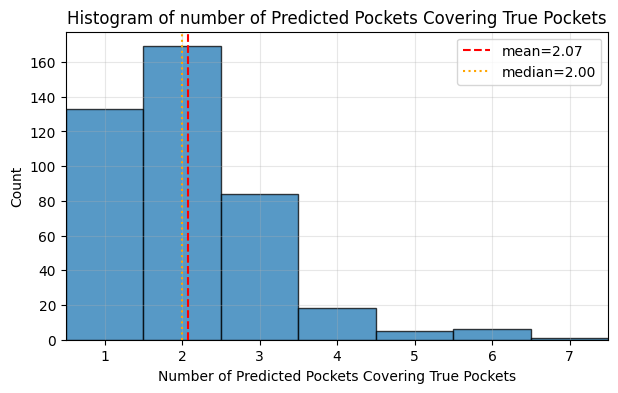

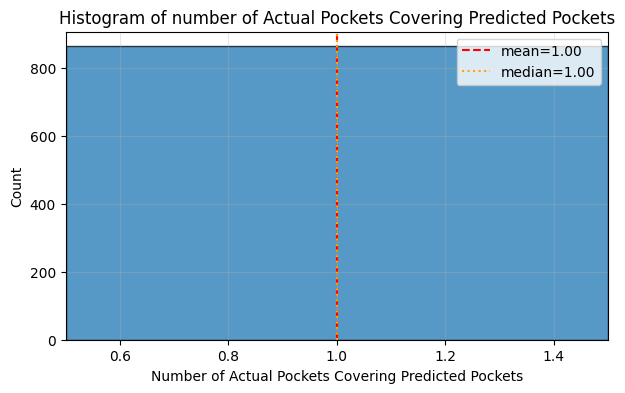

Exception ignored in: <function ResourceTracker.__del__ at 0x151eb1c089a0>
Traceback (most recent call last):
  File "/work/skrhakv/miniconda3/envs/cryptic-nn/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/work/skrhakv/miniconda3/envs/cryptic-nn/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/work/skrhakv/miniconda3/envs/cryptic-nn/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

number_of_pockets = sum([len(i) for i in binding_residues.values()])

mean_br = np.mean(best_residue_overlaps)
median_br = np.median(best_residue_overlaps)
print(f'best_residue_overlap mean={mean_br:.4f}, median={median_br:.4f}')

print(np.sum(np.array(DCCs) < 12) / number_of_pockets, f'({np.sum(np.array(DCCs) < 4) / number_of_pockets})')
print(np.sum(np.array(DCCs_N_plus_K) < 12) / number_of_pockets, f'({np.sum(np.array(DCCs_N_plus_K) < 4) / number_of_pockets})')
print(np.sum(np.array(DCCs_N) < 12) / number_of_pockets, f'({np.sum(np.array(DCCs_N) < 4) / number_of_pockets})')


print('\nSmall binding pockets (less than 10 residues):')
small_pockets_DCCs = [DCCs[i] for i in range(len(DCCs)) if is_small_pocket_DCC[i]]
print(f'Overall DCC < 12: {np.sum(np.array(small_pockets_DCCs) < 12) / len(small_pockets_DCCs):.4f} ({np.sum(np.array(small_pockets_DCCs) < 4) / len(small_pockets_DCCs):.4f})')
small_pockets_DCCs_N_plus_K = [DCCs_N_plus_K[i] for i in range(len(DCCs_N_plus_K)) if is_small_pocket_DCC_N_plus_K[i]]
print(f'N+K DCC < 12: {np.sum(np.array(small_pockets_DCCs_N_plus_K) < 12) / len(small_pockets_DCCs_N_plus_K):.4f} ({np.sum(np.array(small_pockets_DCCs_N_plus_K) < 4) / len(small_pockets_DCCs_N_plus_K):.4f})')
small_pockets_DCCs_N = [DCCs_N[i] for i in range(len(DCCs_N)) if is_small_pocket_DCC_N[i]]
print(f'N DCC < 12: {np.sum(np.array(small_pockets_DCCs_N) < 12) / len(small_pockets_DCCs_N):.4f} ({np.sum(np.array(small_pockets_DCCs_N) < 4) / len(small_pockets_DCCs_N):.4f})')

print('\nLarge binding pockets (10 or more residues):')
large_pockets_DCCs = [DCCs[i] for i in range(len(DCCs)) if not is_small_pocket_DCC[i]]
print(f'Overall DCC < 12: {np.sum(np.array(large_pockets_DCCs) < 12) / len(large_pockets_DCCs):.4f} ({np.sum(np.array(large_pockets_DCCs) < 4) / len(large_pockets_DCCs):.4f})')
large_pockets_DCCs_N_plus_K = [DCCs_N_plus_K[i] for i in range(len(DCCs_N_plus_K)) if not is_small_pocket_DCC_N_plus_K[i]]
print(f'N+K DCC < 12: {np.sum(np.array(large_pockets_DCCs_N_plus_K) < 12) / len(large_pockets_DCCs_N_plus_K):.4f} ({np.sum(np.array(large_pockets_DCCs_N_plus_K) < 4) / len(large_pockets_DCCs_N_plus_K):.4f})')
large_pockets_DCCs_N = [DCCs_N[i] for i in range(len(DCCs_N)) if not is_small_pocket_DCC_N[i]]
print(f'N DCC < 12: {np.sum(np.array(large_pockets_DCCs_N) < 12) / len(large_pockets_DCCs_N):.4f} ({np.sum(np.array(large_pockets_DCCs_N) < 4) / len(large_pockets_DCCs_N):.4f})')  


fig, ax = plt.subplots(figsize=(7, 4))

# Remove zeros
number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros = [i for i in number_of_overlapping_actual_sites_on_predicted_pocket if i != 0]
bins = np.arange(-0.5, max(number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros) + 1.5, 1)
ax.clear()
ax.hist(number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros, bins=bins, color='C0', edgecolor='k', alpha=0.75)
mean_cov = np.mean(number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros)
median_cov = np.median(number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros)
ax.axvline(mean_cov, color='red', linestyle='--', label=f"mean={mean_cov:.2f}")
ax.axvline(median_cov, color='orange', linestyle=':', label=f"median={median_cov:.2f}")
ax.set_title("Histogram of number of Predicted Pockets Covering True Pockets")
ax.set_xlim(0.5, max(number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros) + 0.5)
ax.set_xlabel("Number of Predicted Pockets Covering True Pockets")
ax.set_ylabel("Count")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))

# Remove zeros
number_of_overlapping_predictions_on_actual_pocket_without_zeros = [i for i in number_of_overlapping_predictions_on_actual_pocket if i != 0]
bins = np.arange(-0.5, max(number_of_overlapping_predictions_on_actual_pocket_without_zeros) + 1.5, 1)
ax.clear()
ax.hist(number_of_overlapping_predictions_on_actual_pocket_without_zeros, bins=bins, color='C0', edgecolor='k', alpha=0.75)
mean_cov = np.mean(number_of_overlapping_predictions_on_actual_pocket_without_zeros)
median_cov = np.median(number_of_overlapping_predictions_on_actual_pocket_without_zeros)
ax.axvline(mean_cov, color='red', linestyle='--', label=f"mean={mean_cov:.2f}")
ax.axvline(median_cov, color='orange', linestyle=':', label=f"median={median_cov:.2f}")
ax.set_title("Histogram of number of Actual Pockets Covering Predicted Pockets")
ax.set_xlim(0.5, max(number_of_overlapping_predictions_on_actual_pocket_without_zeros) + 0.5)
ax.set_xlabel("Number of Actual Pockets Covering Predicted Pockets")
ax.set_ylabel("Count")
ax.legend()
ax.grid(alpha=0.3)
plt.show()